> **Примечание для GitHub**
>
> Этот ноутбук подготовлен как публичная версия учебного проекта. Исходные датасеты Яндекс Практикума, содержимое базы данных и файлы с исходными данными не включены в репозиторий.
>
> В репозитории публикуются только авторский код, SQL-запросы, методы анализа, визуализации и текстовые выводы. Сохранённые результаты визуализаций не содержат исходных таблиц и не предназначены для восстановления или выгрузки исходного датасета.
>
> **Важно:** без исходных данных из закрытого учебного окружения этот ноутбук не запускается полностью с нуля. Это сделано намеренно для соблюдения ограничений на распространение учебных данных. Оригинальная версия проекта с доступом к данным хранится отдельно и не публикуется.


# Проект: Яндекс Афиша

- Автор: Поручикова Галина
- Дата: 25.08.2026

###  Введение

**Цель:** Выявить изменения в пользовательских предпочтениях и популярности мероприятий на сервисе Яндекс Афиша в период с июня по октябрь 2024 года, а также проверить гипотезы о различиях в активности пользователей мобильных и стационарных устройств и на основе результатов сформулировать рекомендации для продуктовой команды.

**Задачи:** Загрузить и предобработать данные. Провести исследовательский анализ данных: распределения заказов по сегментам и их сезонные изменения, осенней пользовательской активности, популярных регионов и билетных партнеров. Провести статистический анализ данных: проверить гипотезы о различиях в активности пользователей мобильных и стационарных устройств. Сформулировать общие выводы и рекомендации.

### Описание данных

Для анализа поступили данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Данные состоят из двух датасетов:
- `final_tickets_orders_df.csv` —  информация обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных;
- `final_tickets_events_df.csv` —  информация о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.

**Описание датасета `final_tickets_orders_df`:**
- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то - `нет`.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ - `mobile` для мобильных устройств, `desktop` для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.
- `days_since_prev` - количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

**Описание датасета `final_tickets_events_df`:**
- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

Для конвертации валюты будем использовать **датасет `final_tickets_tenge_df.csv`** с информацией о курсе тенге к российскому рублю за 2024 год. Датасет содержит такие поля:
- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).


### Содержимое проекта

1. Загрузка и знакомство с данными:
    - Загрузка библиотек и датасетов.
    - Знакомство с данными.
2. Предобработка данных:
    - Преобразование типов данных.
    - Проверка данных на пропуски.
    - Изучение значений в столбцах.
    - Проверка дубликатов.
    - Объединение датасетов и создание дополнительных столбцов.
3. Исследовательский анализ данных:
    - Анализ распределения заказов по сегментам и их сезонные изменения.
    - Анализ осенней активности пользователей.
    - Анализ популярных событий и партнеров.
4. Статистический анализ данных:
    - Проверка гипотезы о различии среднего количества заказов на пользователя.
    - Проверка гипотезы о различии среднего времени между заказами.
5. Общий вывод и рекомендации:
    - Общие выводы.
    - Рекомендации.

## Загрузка и знакомство с данными

### Загрузка библиотек и датасетов

Начнем с загрузки библиотеки `pandas` и библиотек для визуализации данных, а также `scipy.stats` для проведения статистических тестов.

In [ ]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

# Загружаем инструменты для проведения статистического анализа
from scipy.stats import ttest_ind

Выгружаем данные в переменные `orders_df`, `events_df`, `tenge_df`:

In [ ]:
# Загрузка исходных датасетов намеренно не включена в публичную версию проекта.
# Данные доступны только в закрытом учебном окружении курса.
# В оригинальной версии проекта здесь создавались переменные orders_df, events_df и tenge_df.
# Публичный репозиторий содержит авторский код анализа и сохранённые результаты визуализаций,
# но не содержит исходные данные или путь к ним.


### Знакомство с данными

Познакомимся с данными датасета `orders_df` — выведем информацию о датафрейме методом `info()` и первые строки методом `head()`:

> **Примечание:** следующие ячейки используют датафреймы `orders_df`, `events_df` и `tenge_df`, которые создавались в закрытой учебной среде. В публичной версии загрузка исходных данных удалена намеренно, поэтому ячейки с вычислениями не предназначены для самостоятельного запуска без предоставления исходных данных. Сохранённые результаты анализа и визуализации оставлены для демонстрации выполненной работы.


In [ ]:
orders_df.info()

In [ ]:
orders_df.head()

Познакомимся с данными датасета `events_df` — выведем информацию о датафрейме методом `info()` и первые строки методом `head()`:

In [ ]:
events_df.info()

In [ ]:
events_df.head()

Познакомимся с данными датасета `tenge_df` — выведем информацию о датафрейме методом `info()` и первые строки методом `head()`:

In [ ]:
tenge_df.info()

In [ ]:
tenge_df.head()

**Датафрейм `orders_df`** содержит 14 столбцов и 290849 строк, в которых представлена информация обо всех заказах билетов.
После первичного анализа данных можно сделать следующие выводы:
- Данные полные, пропуски только в столбце `days_since_prev`, которые возможны по условию. 
- Названия столбцов написаны в едином стиле `snake_case`.
- Значения в столбцах совпадают с тем, что указано в описании.
- Столбцы с датами и временем (`created_dt_msk` и `created_ts_msk`) хранятся как тип данных `object` — их нужно привести к `datetime64`. В остальных столбцах типы данных верные.
- Столбцы `order_id`, `event_id`, `age_limit`, `tickets_count`, `revenue`, `total`, `days_since_prev` - можно оптимизировать с понижением размерности.
   
**Датафрейм `events_df`** содержит 11 столбцов и 22427 строк, в которых представлена информация о событиях, городе и регионе события, о площадке проведения.
После первичного анализа данных можно сделать следующие выводы:
- Данные полные, пропуски нет. 
- Названия столбцов написаны в едином стиле `snake_case`.
- Значения в столбцах совпадают с тем, что указано в описании.
- Типы данных верные.
- Столбцы `event_id`, `city_id`, `venue_id` - можно оптимизировать с понижением размерности.
   
**Датафрейм `tenge_df`** содержит 4 столбца и 357 строк, в которых представлена информация о событиях, городе и регионе события, площадке проведения.
После первичного анализа данных можно сделать следующие выводы:
- Данные полные, пропуски нет. 
- Названия столбцов написаны в едином стиле `snake_case`.
- Значения в столбцах совпадают с тем, что указано в описании.
- Типы данных верные, кроме столбца `data` - нужно привести к типу `datetime64`.
- Столбцы `nominal`, `curs` - можно оптимизировать с понижением размерности.

Таким образом, первичное знакомство с данными показывает, что структура датафреймов соответствует описанию, а значения в столбцах выглядят корректно. Типы данных в целом подобраны верно, за исключением трех столбцов, которые приведем к нужному формату на этапе предобработки, также проведем оптимизацию с понижением размерности для количественных данных. Формально данные полные, однако на этапе предобработки проверим, не встречаются ли в текстовых полях значения, которые могут обозначать пропуски в данных или отсутствие информации.

## Предобработка данных

### Преобразование типов данных

На этапе знакомства с данными было выявлено, что столбцы с датами и временем: `created_dt_msk`, `created_ts_msk`, `data` - нужно привести к типу данных `datetime64`.

Используем метод `to_datetime`.

In [ ]:
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
orders_df['created_ts_msk'] = pd.to_datetime(orders_df['created_ts_msk'])

# Проверим результат преобразования
orders_df[['created_dt_msk', 'created_ts_msk']].dtypes

In [ ]:
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

# Проверим результат преобразования
tenge_df['data'].dtypes

Типы данных успешно преобразованы.

Также на этапе знакомства с данными было принято решение об оптимизации с понижением размерности количественных данных. Для этого будем использовать метод `pd.to_numeriс` аргументом `downcast='integer'` для целочисленных типов, и аргументом `downcast='float'` для вещественных.

In [ ]:
# Целочисленные типы для orders_df
int_cols = ['order_id', 'event_id', 'age_limit', 'tickets_count']
for col in int_cols:
    orders_df[col] = pd.to_numeric(orders_df[col], downcast='integer')

# Вещественные типы для orders_df
float_cols = ['revenue', 'total', 'days_since_prev']
for col in float_cols:
    orders_df[col] = pd.to_numeric(orders_df[col], downcast='float')

# Целочисленные типы для events_df
for col in ['event_id', 'city_id', 'venue_id']:
    events_df[col] = pd.to_numeric(events_df[col], downcast='integer')

# Целочисленные типы для tenge_df
tenge_df['nominal'] = pd.to_numeric(tenge_df['nominal'], downcast='integer')

# Вещественные типы для tenge_df
tenge_df['curs'] = pd.to_numeric(tenge_df['curs'], downcast='float')

# Проверим результат оптимизации
print(orders_df.dtypes)
print(events_df.dtypes)
print(tenge_df.dtypes)

Типы данных были успешно оптимизированы с понижением размерности количественных данных.

In [ ]:
# check
orders_df.info()

### Проверка данных на пропуски

На этапе знакомства с данными мы выявили, что в датафрейме `orders_df` отсутствуют явные пропуски. При этом необходимо дополнительно проверить текстовые поля на наличие значений, которые могут обозначать отсутствие информации. Отдельного внимания требует столбец `days_since_prev`: значение 0 может встречаться у новых пользователей, совершивших только одну покупку, поэтому его не следует однозначно трактовать как пропуск.

Проверим столбцы с категориальными значениями в датафрейме `orders_df`.

In [ ]:
# Список категориальных столбцов для проверки
cols_to_check = ['age_limit', 'cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name']

for col in cols_to_check:
    unique_vals = orders_df[col].sort_values().unique()
    print(f"{col}: {unique_vals}")

Значения, указывающие на пропуски, обнаружены только в столбце `cinema_circuit`, но они примены здесь по условию - если это не сеть кинотеатров. Остальные значения корректны.

Теперь проверим датафрейм `events_df`.

In [ ]:
# Список категориальных столбцов для проверки
cols_to_check = ['event_type_main', 'event_type_description', 'region_name', 'city_name']

for col in cols_to_check:
    unique_vals = events_df[col].sort_values().unique()
    print(f"{col} : {unique_vals} ")

Значения, указывающие на пропуски, не обнаружены.

### Изучение значений в столбцах

Далее проверим количественные значения на распределение и наличие выбросов. 

Начнем со столбца `revenue` датафрейма `orders_df`. Выведем статистическую информацию при помощи метода `descride`.

In [ ]:
# Разделим на рубли и тенге
orders_rub = orders_df[orders_df['currency_code'] == 'rub']
orders_kzt = orders_df[orders_df['currency_code'] == 'kzt']

print(orders_rub['revenue'].describe())
print(orders_kzt['revenue'].describe())

По статистической информации о выручке сделаем вывод, что основная доля заказов приходится на рубли - 285780 заказов, а заказы в тенге - всего 5 069. При этом средняя выручка в рублях составляет 547.57 рубля, а медианное значение — 346.10 рубля, что говорит о том, что большая часть заказов находится в невысоком ценовом диапазоне. Большой разброс значений: от отрицательных значений (-90.76 рубля) до 81174.54 рубля, а стандартное отклонение составляет 871.52 рубля, что указывает на наличие значительных выбросов. В заказах в тенге средняя выручка составляет 4995.21 тенге при медиане 3698.83 тенге, минимальное значение равно нулю, а максимальное достигает 26425.86 тенге. 

Визуализируем распределение при помощи диаграммы размаха.

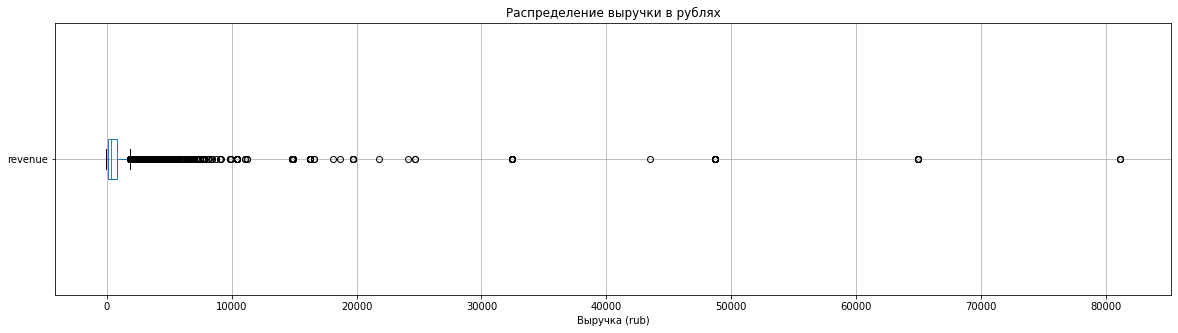

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 5))

# Строим диаграмму размаха значений в столбце seats
orders_rub.boxplot(column='revenue', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение выручки в рублях')
plt.xlabel('Выручка (rub)')

# Выводим график
plt.show()

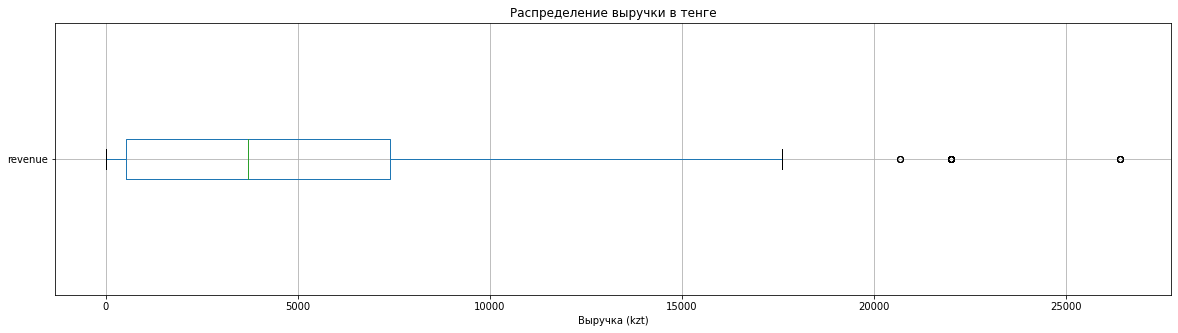

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 5))

# Строим диаграмму размаха значений в столбце seats
orders_kzt.boxplot(column='revenue', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение выручки в тенге')
plt.xlabel('Выручка (kzt)')

# Выводим график
plt.show()

Диаграммы размаха подтверждают наличие выбросов, значений данных, которые заметно отличаются от остальных. 

Для устранения выбросов в обеих валютах применим фильтрацию по 99-му процентилю.

In [ ]:
# Фильтрация для rub
rub_99 = orders_rub['revenue'].quantile(0.99)
orders_rub_clean = orders_rub[orders_rub['revenue'] <= rub_99]

# Фильтрация для kzt
kzt_99 = orders_kzt['revenue'].quantile(0.99)
orders_kzt_clean = orders_kzt[orders_kzt['revenue'] <= kzt_99]

# Объединяем
orders_clean = pd.concat([orders_rub_clean, orders_kzt_clean], ignore_index=True)

Поверим сколько строк было удалено после фильтрации.

In [ ]:
print(f"\nБыло строк: {len(orders_df)}")
print(f"Стало строк: {len(orders_clean)}")
print(f"Удалено строк: {len(orders_df) - len(orders_clean)}")
print(f"Удалено строк: {((len(orders_df) - len(orders_clean)) / len(orders_df) * 100):.2f}%")

После фильтрации данных из 290849 строк удалено 2887 строк, что составляет 1% от общего объёма. Это незначительная потеря, которая не исказит результаты анализа.

Теперь проверим столбец `tickets_count` датафрейма `orders_clean`. Выведем статистическую информацию при помощи метода `descride`.

In [ ]:
orders_clean['tickets_count'].describe()

Визуализируем распределение при помощи диаграммы размаха.

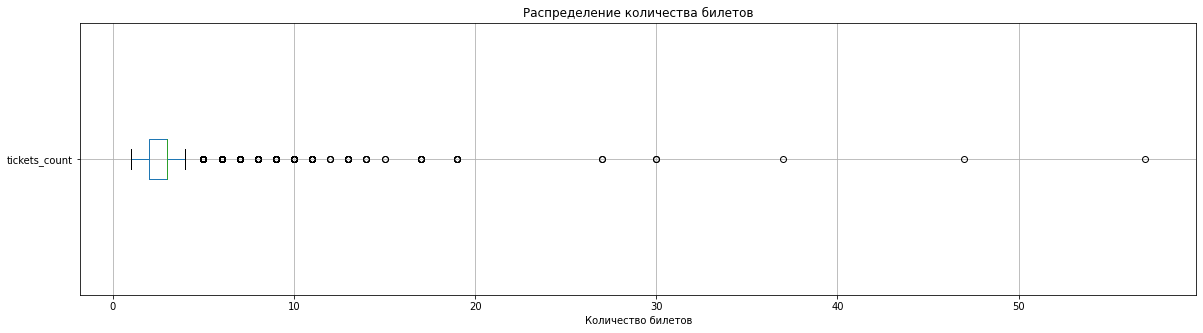

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 5))

# Строим диаграмму размаха значений в столбце seats
orders_clean.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества билетов')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

Количество билетов в заказе имеет значения от 1 до 57, при этом среднее составляет 2.74 билета. Медианное значение равно 3 билетам, а 75-й процентиль также составляет 3 билета, что говорит о том, что три четверти всех заказов содержат не более 3 билетов. При этом были обнаружены единичные заказы с аномально высоким количеством билетов (до 57), что может свидетельствовать о групповых бронированиях.

### Проверка дубликатов

Далее проверим наличие явных дубликатов в датафреймах.

In [ ]:
print(orders_clean.duplicated().sum())
print(events_df.duplicated().sum())
print(tenge_df.duplicated().sum())

В датафреймах нет полных дубликатов строк.

Проверим на неявные дубликаты по бронированию билета без учёта идентификаторов заказа `order_id`.

In [ ]:
# Создаем список столбцов 
duplicate_columns = [col for col in orders_clean.columns if col != 'order_id']

# Находим неявные дубликаты
duplicates_count = orders_clean.duplicated(subset=duplicate_columns).sum()
duplicates_count

Неявных дубликатов было выявлено - 30. Удалим их.

In [ ]:
# Удаляем дубликаты (оставляем только первое вхождение)
orders_clean = orders_clean.drop_duplicates(subset=duplicate_columns, keep='first')

len(orders_clean)

После удаления неявных дубликатов осталось 287932 строки.

### Объединение датасетов и создание дополнительных столбцов

Теперь для дальнейшего анализа объединим наши датафреймы.

In [ ]:
# Пример с дубликатами
df_left = pd.DataFrame({'id': [1, 2, 4, 5], 'revenue':[100, 200, 300, 400]})
df_right = pd.DataFrame({'id': [1, 1, 2, 2, 3], 'name_event': ['A', 'B', 'C', 'D', 'E']})
display(df_left, df_right)

In [ ]:
# Пример с дубликатами
pd.merge(df_left, df_right, on='id', how='left')

In [ ]:
# Пример БЕЗ дубликатов

df_left = pd.DataFrame({'id': [1, 2, 4, 5], 'revenue':[100, 200, 300, 400]})
df_right = pd.DataFrame({'id': [1, 2, 3], 'name_event': ['A', 'B', 'C']})
display(df_left, df_right)

In [ ]:
pd.merge(df_left, df_right, on='id', how='left')

Перед объединением датафреймов проверим уникальность ключа `event_id` в таблице `events_df`. Это необходимо, чтобы убедиться, что одному мероприятию соответствует только одна запись. При наличии дубликатов объединение может привести к увеличению количества строк и искажению данных.

In [ ]:
events_df['event_id'].duplicated().sum()

Дубликатов не обнаружено, значит каждому мероприятию соответствует только одна запись. Теперь объединим данные о заказах с информацией о соответствующих мероприятиях по ключу `event_id`. 

In [ ]:
df = orders_clean.merge(events_df, on='event_id', how='left')

# Выведем информацию о получившемся датафрейме
df.info()

В объединенном датафрейме `df` были обнаружены пропуски в столбцах, содержащих информацию о событиях. Это связано с тем, что из датасета `events_df` были исключены фильмы, так как их доля в общем объеме заказов незначительна. Всего таких записей 238, что составляет 0.08% от общего количества заказов. Принято решение удалить эти записи из датафрейма.

In [ ]:
df = df.dropna(subset=['event_name'])

Для дальнейшего анализа нам необходимо создать несколько столбцов:
- `revenue_rub` — привести выручку с заказа к единой валюте — российскому рублю.
- `one_ticket_revenue_rub` — рассчитать выручку с продажи одного билета на мероприятие.
- `month` — выделить месяц оформления заказа в отдельный столбец.
- `season` — столбец с информацией о сезонности, включая категории: лето, осень, зима, весна.

In [ ]:
# Создаем словарь с курсом на каждый день
currency_dict = tenge_df.set_index('data')['curs'].to_dict()

# Функция для конвертации валюты
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        date = row['created_dt_msk']
        rate = currency_dict[date] 
        return row['revenue'] / 100 * rate
    else:
        return row['revenue']
    
# Создаем новые столбцы
df['revenue_rub'] = df.apply(convert_to_rub, axis=1)
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']
df['month'] = df['created_dt_msk'].dt.month

def get_season(month):
    if month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    elif month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    else:
        return None

df['season'] = df['month'].apply(get_season)

Проверим, что после конвертации в столбце `revenue_rub` не появились пропуски. Это позволит убедиться, что для всех заказов, участвующих в анализе, рассчитана выручка в рублях.

In [ ]:
df['revenue_rub'].isna().sum()

Пропусков в `revenue_rub` не обнаружено, поэтому выручка для всех заказов представлена в единой валюте — российских рублях.

После создания столбца `season` проверим корректность распределения месяцев по сезонам. Для этого сгруппируем данные по месяцу и посмотрим, какой сезон соответствует каждому значению `month`.

In [ ]:
df.groupby('month')['season'].unique()

Проверка показала, что все месяцы корректно отнесены к соответствующим сезонам: июнь, июль и август — к лету, сентябрь и октябрь — к осени. Некорректных соответствий между месяцем и сезоном не обнаружено.

Этап предобработки закончен. 

Выведем информацию об итоговом датафрейме `df`, который будем использовать для дальнейших исследовательских и статистических анализов.

In [ ]:
# check
# я добавил импорт, чтобы показать пример 
import numpy as np

In [ ]:
# check

dfe = pd.DataFrame({'month': [-1, 0, 3, 4, 8, 10, 7.999999, 12, np.nan, 13]})
dfe['season'] = dfe['month'].apply(get_season)
dfe

In [ ]:
df.info()

**Вывод:** В ходе предобработки данных были выполнены следующие действия: преобразованы типы данных для столбцов с датами и временем, а также выполнено снижение размерности для количественных столбцов. Проверка категориальных значений показала, что все столбцы содержат корректные данные. Для обработки выбросов в столбце `revenue` применена фильтрация по 99-му процентилю отдельно для каждой валюты. Явные дубликаты в данных отсутствуют, при этом обнаружено и удалено 30 неявных дубликатов. Датафреймы заказов и событий объединены в единый. Для дальнейшего анализа созданы новые столбцы: `revenue_rub` для выручки в рублях с учетом конвертации из тенге, `one_ticket_revenue_rub` для выручки с одного билета, `month` для месяца оформления заказа и `season` для сезона. 

**Итоги очистки данных:**

- Количество строк до очистки - 290849.
- Количество строк после очистки - 287694.
- Количество удаленных строк - 3155.
- Доля удаленных строк - 1.08%.

Было удалено незначительное количество строк. В результате предобработки получен датафрейм, готовый к дальнейшему исследовательскому и статистическим анализам.

In [ ]:
# check
df.describe().round(1)

По результатам описательной статистики в данных обнаружены отрицательные значения в денежных показателях: минимальное значение `revenue` составляет -90,8, а `total` - -358,9. Такие значения могут соответствовать операциям возврата, которые отличаются от обычной покупки билетов и могут искажать результаты анализа пользовательской активности. Также в данных присутствуют нулевые значения денежных показателей, влияние которых необходимо учитывать при проведении статистического анализа. Поэтому перед проверкой гипотез дополнительно изучим такие записи и определим, какие из них следует исключить из выборок.

## Исследовательский анализ данных

Перейдем к исследовательскому анализу данных.

### Анализ распределения заказов по сегментам и их сезонные изменения

Изучим распределение заказов по сегментам и их сезонные изменения. 

Для каждого месяца найдем количество заказов и визуализируем результаты. 

In [ ]:
# Количество заказов по месяцам
month_orders = df['month'].value_counts().sort_index()
month_orders

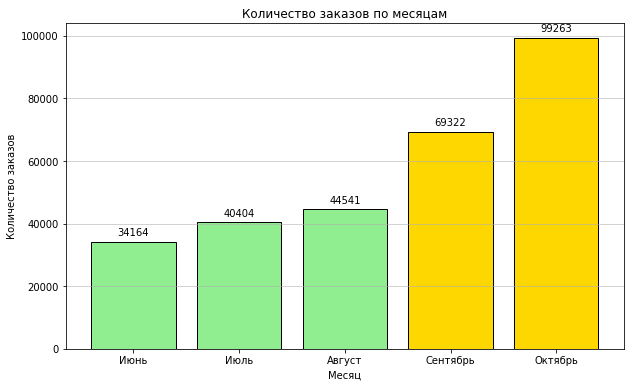

In [ ]:
# Визуализируем при помощи столбчатой диаграммы
months = ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь']
colors = ['lightgreen', 'lightgreen', 'lightgreen', 'gold', 'gold']

plt.figure(figsize=(10, 6))

plt.bar(months, month_orders.values, color=colors, edgecolor='black')

plt.text(0, 36164, '34164', ha='center')
plt.text(1, 42404, '40404', ha='center')
plt.text(2, 46541, '44541', ha='center')
plt.text(3, 71322, '69322', ha='center')
plt.text(4, 101263, '99263', ha='center')

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.7)

plt.show()

Анализ количества заказов по месяцам показывает устойчивый рост активности с июня по октябрь 2024 года. В июне было зафиксировано 34164 заказа, в июле количество увеличилось до 40404 заказов, в августе до 44541 заказа. С наступлением осени, в сентябре, количество заказов составило 69322, а в октябре достигло максимума за весь рассматриваемый период - 99263 заказа. 

Далее для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. Визуализируем результаты.

In [ ]:
# Создадим датафреймы для лета и осени
summer_df = df[df['season'] == 'лето']
autumn_df = df[df['season'] == 'осень']

In [ ]:
# Распределение по типам мероприятий
summer_event = summer_df['event_type_main'].value_counts(normalize=True) * 100
autumn_event = autumn_df['event_type_main'].value_counts(normalize=True) * 100

# Количество заказов по месяцам
monthly_event = pd.crosstab(df['event_type_main'], df['month'])

# Объединяем относительные и абсолютные значения в одну таблицу
event_df = pd.DataFrame({
    'Лето, %': summer_event,
    'Осень, %': autumn_event
}).fillna(0)

# Добавляем абсолютное количество заказов по месяцам
event_df = event_df.join(
    monthly_event[[6, 7, 8, 9, 10]],
    how='outer'
).fillna(0)

# Переименовываем месяцы
event_df = event_df.rename(columns={
    6: 'Июнь',
    7: 'Июль',
    8: 'Август',
    9: 'Сентябрь',
    10: 'Октябрь'
})

# Сортируем типы мероприятий по доле заказов летом
event_df = event_df.sort_values('Лето, %', ascending=False)

# Округляем значения
event_df['Лето, %'] = event_df['Лето, %'].round(1)
event_df['Осень, %'] = event_df['Осень, %'].round(1)

event_df

Визуализируем доли заказов по типам мероприятий при помощи столбчатой диаграммы.

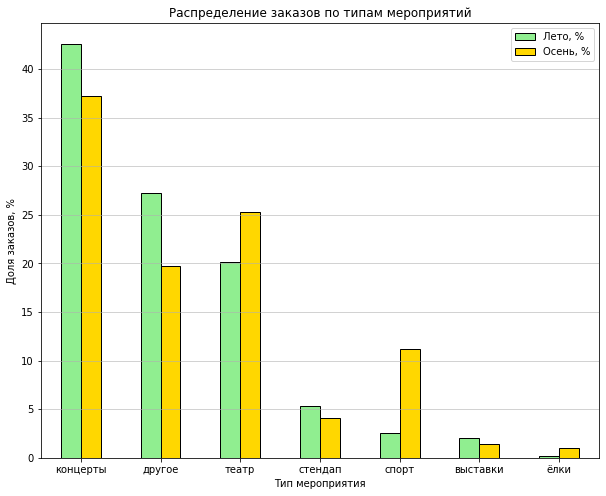

In [ ]:
event_df[['Лето, %', 'Осень, %']].plot(kind='bar', color=['lightgreen', 'gold'], edgecolor='black', figsize=(10, 8))

plt.title('Распределение заказов по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.7)

plt.show()

Анализ показывает, что с июня по октябрь количество заказов увеличивалось практически по всем типам мероприятий. Наиболее востребованными категориями остаются концерты и другие мероприятия: летом на концерты приходилось 42.6% заказов, а осенью — 37.2%. При этом в абсолютных значениях количество заказов на концерты выросло с 15489 в июне до 37775 в октябре.

Для театра, напротив, наблюдается одновременно рост абсолютного количества и доли заказов: с 7354 заказов в июне до 25098 в октябре, а доля увеличилась с 20.1% летом до 25.3% осенью.

Наиболее заметная динамика наблюдается у категории спорт. Количество заказов выросло с 261 в июне до 10907 в октябре, а доля заказов увеличилась с 2.5% летом до 11.2% осенью. Это говорит о существенном повышении интереса к спортивным мероприятиям в осенний период.

Таким образом, осенью наблюдается не только общий рост количества заказов, но и изменение структуры спроса: относительно снижается доля концертов и других мероприятий, тогда как увеличивается доля театра и особенно спортивных мероприятий. При этом в абсолютных значениях количество заказов растет практически по всем категориям.

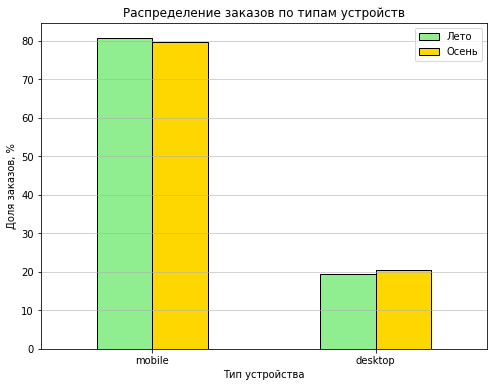

In [ ]:
# Распределение по типам устройств
summer_device = summer_df['device_type_canonical'].value_counts(normalize=True) * 100
autumn_device = autumn_df['device_type_canonical'].value_counts(normalize=True) * 100

print(f"Лето:\n {summer_device.round(1)}")
print(f"Осень:\n {autumn_device.round(1)}")

# Объединяем в один датафрейм
device_df = pd.DataFrame({'Лето': summer_device, 'Осень': autumn_device}).fillna(0)

# Визуализируем результат
device_df.plot(kind='bar', color=['lightgreen', 'gold'], edgecolor='black', figsize=(8, 6))

plt.title('Распределение заказов по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.7)

plt.show()

По типу устройств распределение заказов летом и осенью практически не меняется. Летом мобильные устройства составляют 80.6%, десктопы - 19.4%. Осенью доля мобильных устройств - 79.7%, а десктопов - 20.3%. 

Таким образом, можно сделать вывод, что пользователи в обоих сезонах преимущественно оформляют заказы с мобильных устройств, и сезонность не оказывает существенного влияния на выбор устройства.

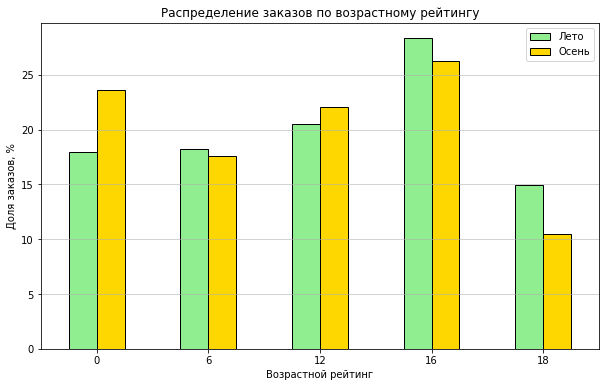

In [ ]:
# Распределение по возрастному рейтингу
summer_age = summer_df['age_limit'].value_counts(normalize=True).sort_index() * 100
autumn_age = autumn_df['age_limit'].value_counts(normalize=True).sort_index() * 100

print(f"Лето:\n {summer_age.round(1)}")
print(f"Осень:\n {autumn_age.round(1)}")

# Объединяем в один датафрейм
age_df = pd.DataFrame({'Лето': summer_age, 'Осень': autumn_age}).fillna(0)

# Визуализируем результат
age_df.plot(kind='bar', color=['lightgreen', 'gold'], edgecolor='black', figsize=(10, 6))

plt.title('Распределение заказов по возрастному рейтингу')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.7)

plt.show()

По возрастному рейтингу летом наибольшая доля заказов приходится на категорию 16+ (28.3%), затем следуют 12+ (20.5%), 6+ (18.2%), 0+ (18.0%) и 18+ (15.0%). 

Осенью структура распределения меняется: растет доля категории 0+ - 23.6%, а также категории 12+ - 22.1%. При этом снижается доля категории 16+ - 26.2% и категории 18+ - 10.4%.

Возможно, осенью аудитория смещается в сторону семейных мероприятий, так как начинается учебный год. 

Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью. 

Для каждого типа мероприятия рассчитаем среднее значение выручки с одного билета, затем найдем относительное изменение осенних значений по сравнению с летними. Результат визуализируем.

In [ ]:
summer_ticket = summer_df.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_ticket = autumn_df.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Объедим и посчитаем изменение
ticket_df = pd.DataFrame({'Лето': summer_ticket, 'Осень': autumn_ticket})
ticket_df['Относительное изменение'] = ((ticket_df['Осень'] - ticket_df['Лето']) / ticket_df['Лето'] * 100).round(1)

ticket_df

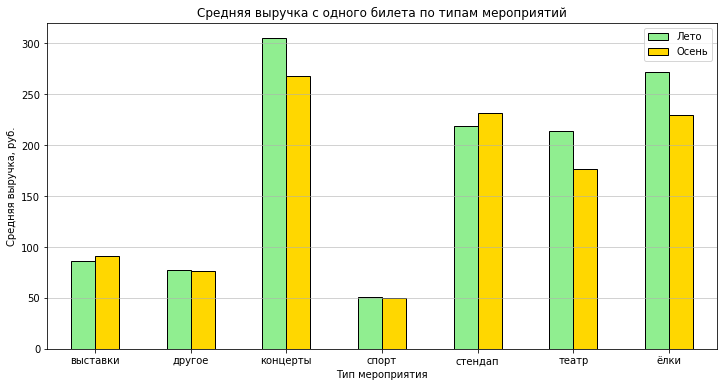

In [ ]:
ticket_df[['Лето', 'Осень']].plot(kind='bar', figsize=(12, 6), color=['lightgreen', 'gold'], edgecolor='black')

plt.title('Средняя выручка с одного билета по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка, руб.')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.7)

plt.show()

Летом самые высокие показатели средней выручки с одного билета наблюдаются у концертов - 304.7 рубля, елок - 271.4 рубля и стендапа - 218.5 рубля. Самая низкая выручка зафиксирована у спортивных мероприятий - 50.8 рубля и категории другое - 77.4 рубля.

Осенью средняя выручка с одного билета снижается у большинства типов мероприятий. Наибольшее падение наблюдается у театра - на 17.8% (до 176.0 рублей), елок - на 15.4% (до 229.6 рублей) и концертов - на 12.0% (до 268.1 рублей). При этом выручка выросла у стендапа на 5.8% (до 231.1 рубля) и у выставок на 4.8% (до 90.6 рубля). Категория другое и спорт показали незначительное снижение - около 1.7% и 1.6% соответственно.

Таким образом, с приходом осени средняя выручка с одного билета в большинстве категорий снижается. Возможные причины: осенью увеличивается количество мероприятий с более доступными ценами, либо меняется структура спроса - зрители начинают выбирать более бюджетные варианты.

### Анализ осенней активности пользователей

Изучим активность пользователей за сентябрь и октябрь 2024 года.

Проанализируем динамику изменений по дням для:
- общего числа заказов;
- количества активных пользователей;
- средней стоимости одного билета;
- среднего количества заказов на одного пользователя.

Создадим для этого сводную таблицу.

In [ ]:
autumn_days = autumn_df.groupby('created_dt_msk').agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Рассчитываем среднее количество заказов на пользователя
autumn_days['orders_user'] = autumn_days['orders'] / autumn_days['users']

autumn_days

Полученные результаты визуализируем с помощью линейных графиков. 

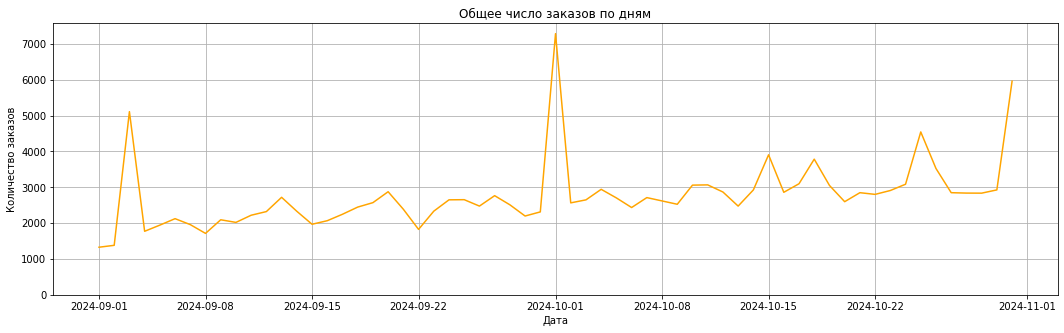

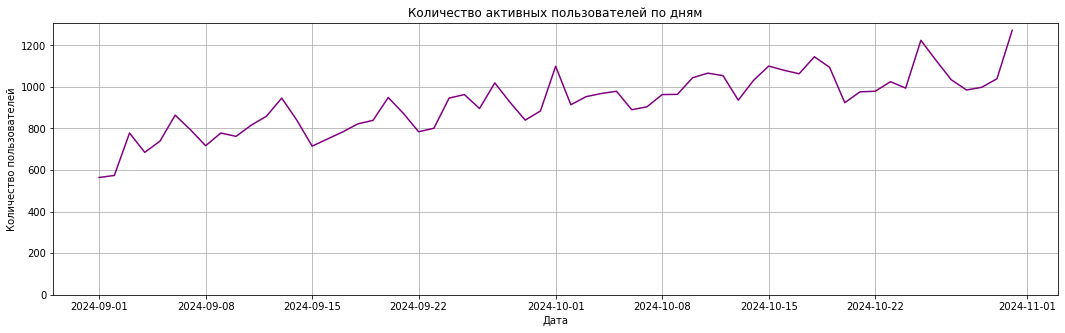

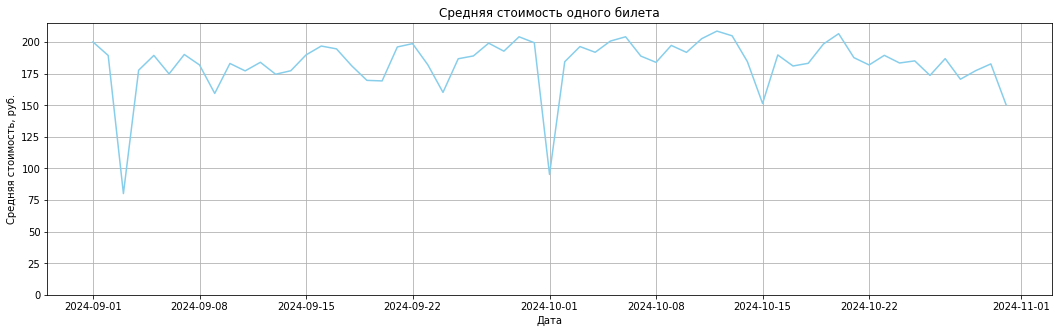

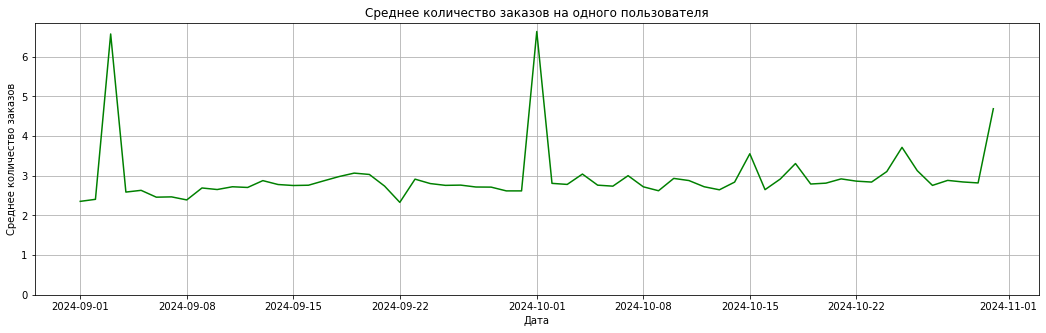

In [ ]:
# Общее число заказов
plt.figure(figsize=(18, 5))

plt.plot(autumn_days['created_dt_msk'], autumn_days['orders'], color='orange')

plt.title('Общее число заказов по дням')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid()
plt.ylim(bottom=0)

plt.show()

# Количество активных пользователей
plt.figure(figsize=(18, 5))

plt.plot(autumn_days['created_dt_msk'], autumn_days['users'], color='purple')

plt.title('Количество активных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.ylim(bottom=0)

plt.show()

# Средняя стоимость одного билета
plt.figure(figsize=(18, 5))

plt.plot(autumn_days['created_dt_msk'], autumn_days['avg_ticket_price'], color='skyblue')

plt.title('Средняя стоимость одного билета')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость, руб.')
plt.grid()
plt.ylim(bottom=0)

plt.show()

# Среднее количество заказов на одного пользователя
plt.figure(figsize=(18, 5))

plt.plot(autumn_days['created_dt_msk'], autumn_days['orders_user'], color='green')

plt.title('Среднее количество заказов на одного пользователя')
plt.xlabel('Дата')
plt.ylabel('Среднее количество заказов')
plt.grid()
plt.ylim(bottom=0)

plt.show()

За осенний период с сентября по октябрь наблюдается устойчивый рост пользовательской активности. Количество заказов постепенно увеличивается: в сентябре среднее значение составляет 1800–2200 заказов в день, тогда как в октябре этот показатель вырастает примерно до 3000 заказов. Динамика активных пользователей повторяет эту тенденцию — если в начале сентября количество активных пользователей в день составляло около 550 человек, а к концу октября достигло примерно 1280 пользователей.

Среднее число заказов на одного пользователя в обычные дни держится на уровне 2.5–3 заказов, что говорит о стабильном поведении аудитории. Однако на протяжении осени выделяются три пиковых дня с аномальной активностью: 3 сентября, 1 и 31 октября. В эти дни резко возрастает общее количество заказов, а среднее число заказов на пользователя достигает 4.8–6.8 — значительно выше обычного уровня.

Средняя стоимость одного билета на протяжении осени колеблется в пределах 170–200 рублей и не показывает устойчивого роста. Примечательно, что в пиковые дни активности наблюдается резкое снижение средней цены билета: до 80 рублей 3 сентября, около 95 рублей 1 октября и 150 рублей 31 октября. Это позволяет предположить, что данные дни совпадают с проведением маркетинговых акций или распродаж, когда билеты продавались по сниженным ценам, что привлекло внимание большего числа пользователей и стимулировало их оформлять заказы более активно.

Таким образом, осенью 2024 года фиксируется устойчивый рост числа заказов и активной аудитории. В обычные дни среднее количество заказов на одного пользователя остается относительно стабильным, несмотря на отдельные пиковые даты, что свидетельствует о стабильном уровне пользовательской активности в обычные дни. Пиковые дни активности совпадают с периодами снижения средней стоимости билета, что может указывать на эффективность ценовых акций как инструмента привлечения пользователей и стимулирования спроса.

Изучим недельную цикличность. Выделим день недели и сравним пользовательскую активность в будни и выходные.

In [ ]:
autumn = autumn_df.copy()

# Добавляем день недели
autumn['day_of_week'] = autumn['created_dt_msk'].dt.dayofweek + 1

# Группируем по дням недели
weekly_stats = autumn.groupby('day_of_week').agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique')
)

weekly_stats['orders_user'] = weekly_stats['orders'] / weekly_stats['users']

weekly_stats.round(1)

Визуализируем при помощи столбчатых диаграмм.

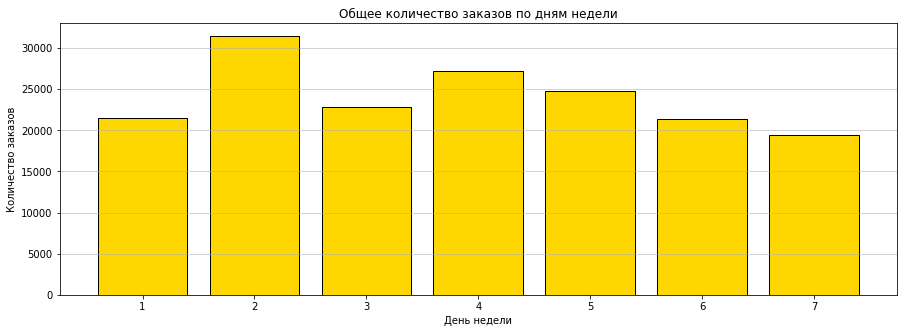

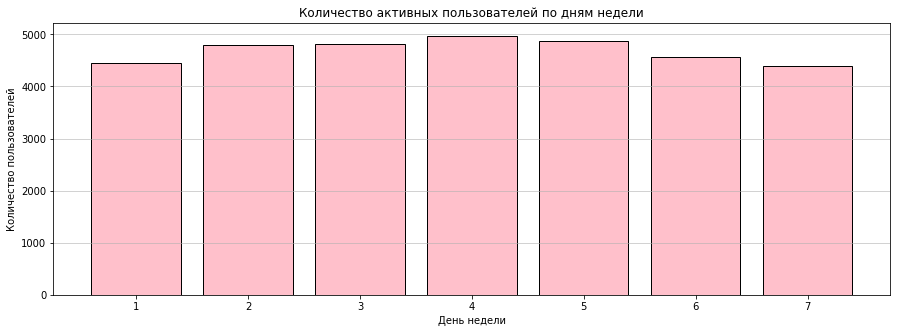

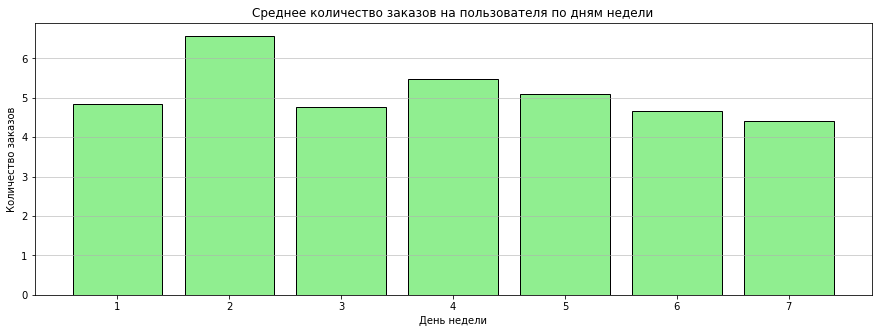

In [ ]:
# Общее количество заказов по дням недели
plt.figure(figsize=(15, 5))

plt.bar(weekly_stats.index, weekly_stats['orders'], color='gold', edgecolor='black')

plt.title('Общее количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(weekly_stats.index)
plt.grid(axis='y', alpha=0.7)

plt.show()

# Количество активных пользователей по дням недели
plt.figure(figsize=(15, 5))

plt.bar(weekly_stats.index, weekly_stats['users'], color='pink', edgecolor='black')

plt.title('Количество активных пользователей по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.xticks(weekly_stats.index)
plt.grid(axis='y', alpha=0.7)

plt.show()

# Среднее количество заказов на пользователя по дням недели
plt.figure(figsize=(15, 5))

plt.bar(weekly_stats.index, weekly_stats['orders_user'], color='lightgreen', edgecolor='black')

plt.title('Среднее количество заказов на пользователя по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(weekly_stats.index)
plt.grid(axis='y', alpha=0.7)

plt.show()


Анализ недельной активности показывает, что наибольшее количество заказов приходится на вторник - 31480 заказов. На втором месте четверг - 27166 заказов, на третьем месте пятница - 24826 заказов. Низкая активность в понедельник (21511 заказов) и субботу (21333 заказа). Самая низкая активность наблюдается в воскресенье - 19388 заказов.

По количеству активных пользователей пик приходится на четверг - 4970 пользователей, на втором месте пятница - 4870 , на третьем среда - 4812 пользователей. Мало пользователей в понедельник (4445) и субботу (4571), а меньше всего пользователей в воскресенье - 4394.

Среднее число заказов на одного пользователя максимально во вторник - 6.6 заказов на пользователя. В остальные дни этот показатель колеблется в диапазоне 4.4-5.5 заказов на пользователя. Самые низкие значения зафиксированы в воскресенье (4.4 заказа) и субботу (4.7).

Таким образом, пользовательская активность распределена неравномерно в течение недели. Пик активности приходится на вторник и четверг и снижается к выходным, особенно к воскресенью. В понедельник активность тоже еще низкая.

В целом, середина и конец рабочей недели являются наиболее активными периодами, а выходные дни демонстрируют заметный спад активности.

### Анализ популярных событий и билетных партнеров

Далее проанализируем как события распределены по регионам и билетным партнерам. Выделим ключевые регионы и партнеров (топ-7), которые вносят наибольший вклад в выручку.

Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов. Исследуем не только абсолютные значения, но и доли.

In [ ]:
region_df = autumn_df.groupby('region_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count')
).sort_values('events', ascending=False)

# Добавляем доли
region_df['events_share'] = (region_df['events'] / region_df['events'].sum() * 100).round(1)
region_df['orders_share'] = (region_df['orders'] / region_df['orders'].sum() * 100).round(1)

region_df.head(7)

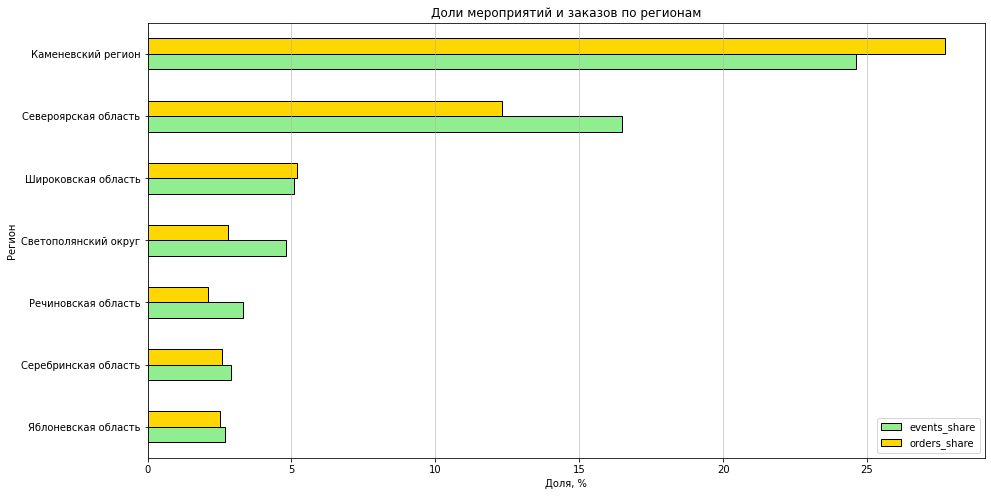

In [ ]:
# Визуализируем при помощи столбчатой диаграммы
top_regions = region_df.head(7).iloc[::-1]

top_regions[['events_share', 'orders_share']].plot(kind='barh', figsize=(15, 8), color=['lightgreen', 'gold'], edgecolor='black')

plt.title('Доли мероприятий и заказов по регионам')
plt.ylabel('Регион')
plt.xlabel('Доля, %')
plt.grid(axis='x', alpha=0.7)

plt.show()

Лидером по обоим показателям является Каменевский регион, на который приходится 24.6% всех мероприятий и 27.7% всех заказов осенью. На втором месте Североярская область с 16.5% мероприятий и 12.3% заказов. Остальные регионы из топ-7 имеют долю не более 5.1% по мероприятиям и 5.2% по заказам, что значительно меньше, чем у лидеров.

Таким образом, наблюдается высокая концентрация мероприятий и заказов в двух регионах-лидерах, в то время как остальные регионы вносят значительно меньший вклад в общие показатели. Это может указывать на неравномерное распределение событий по регионам.

Для каждого билетного партнера посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Исследуем не только абсолютные значения, но и доли.

In [ ]:
service_df = autumn.groupby('service_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).sort_values('revenue', ascending=False)

# Добавляем доли
service_df['events_share'] = (service_df['events'] / service_df['events'].sum() * 100).round(1)
service_df['orders_share'] = (service_df['orders'] / service_df['orders'].sum() * 100).round(1)
service_df['revenue_share'] = (service_df['revenue'] / service_df['revenue'].sum() * 100).round(1)

service_df.head(7)

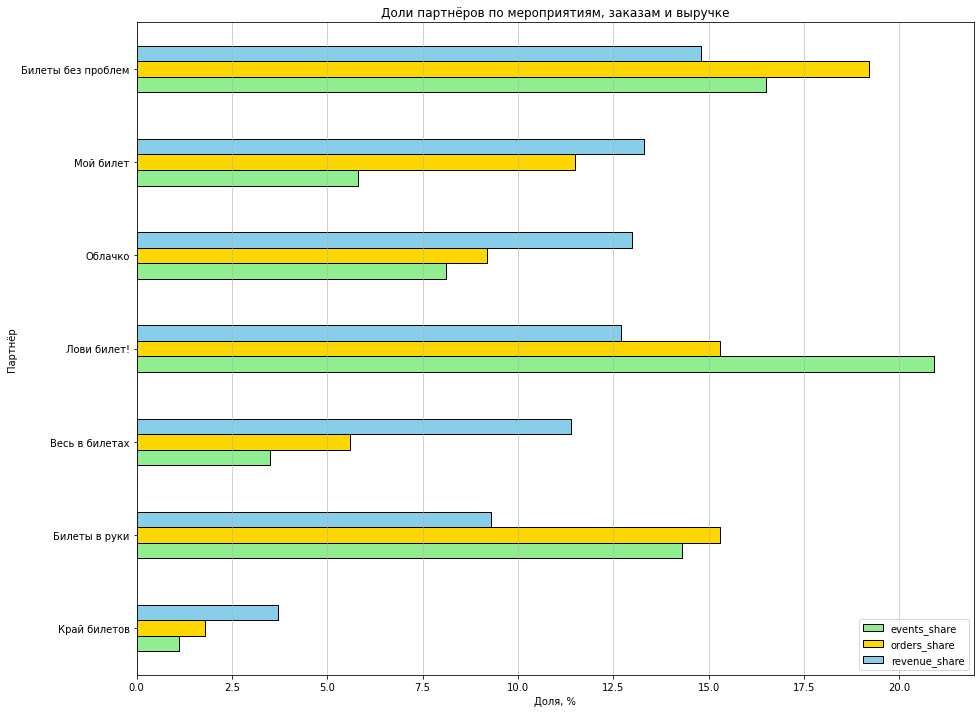

In [ ]:
# Визуализируем при помощи столбчатой диаграммы
top_services = service_df.head(7).iloc[::-1]

top_services[['events_share', 'orders_share', 'revenue_share']].plot(kind='barh', figsize=(15, 12), 
                                                                     color=['lightgreen', 'gold', 'skyblue'], edgecolor='black')
plt.title('Доли партнёров по мероприятиям, заказам и выручке')
plt.ylabel('Партнёр')
plt.xlabel('Доля, %')
plt.grid(axis='x', alpha=0.7)

plt.show()

Среди билетных партнеров осенью явным лидером по выручке является "Билеты без проблем" с долей 14.8%, который также лидирует по числу заказов (19.2%) и занимает второе место по количеству мероприятий (16.5%). На втором месте по выручке "Мой билет" с 13.3%, при этом он имеет относительно небольшое количество мероприятий (5.8%), но высокую долю заказов (11.5%), что говорит о популярности его событий. Третье место занимает "Облачко" с 13.0% выручки и долей заказов 9.2%.

При этом "Лови билет!" имеет наибольшее количество мероприятий (20.9%), но по выручке находится только на четвертом месте (12.7%), что может указывать на более низкую стоимость билетов у этого партнера. Также стоит отметить "Билеты в руки", которые имеют 14.3% мероприятий и 15.3% заказов, но долю выручки только 9.3%, что говорит о том, что их билеты стоят дешевле среднего.

Таким образом, осенью наблюдается концентрация рынка вокруг нескольких ключевых игроков. Топ-3 партнера обеспечивают около 41% всей выручки. При этом лидер по количеству мероприятий не всегда является лидером по выручке, что свидетельствует о различиях в ценовой политике и форматах мероприятий у разных партнеров.

**Вывод по исследовательскому анализу данных.**

В ходе исследовательского анализа данных за период с июня по октябрь 2024 года было выявлено:

- Сезонный рост активности. Количество заказов увеличивается от лета к осени, достигая пика в октябре. При этом осенью меняется структура спроса: растёт доля театра и спорта.

- Устройства. Пользователи преимущественно оформляют заказы с мобильных устройств в обоих сезонах.

- Возрастной рейтинг. Осенью смещение в сторону категорий 0+ и 12+, что может свидетельствовать о росте семейного спроса.

- Средняя выручка на билет. Снижается осенью в большинстве категорий, особенно сильно - у театра, концертов и елок. Исключение - стендап и выставки, где выручка выросла.

- Осенняя активность. Наблюдается устойчивый рост числа заказов и уникальных пользователей. Недельная цикличность: пик - вторник и четверг, спад - выходные. 

- Регионы и партнёры. Рынок сильно концентрирован: два региона (Каменевский и Североярская область) дают около 40% всех заказов. Среди партнёров топ-3 обеспечивают около 41% выручки, при этом лидер по числу мероприятий не всегда лидирует по выручке.

Таким образом, исследовательский анализ завершён. Далее переходим к статистическому анализу данных.

## Статистический анализ данных

Нужно проверить две гипотезы относительно активности пользователей мобильных и стационарных устройств. 

Начнём с проверки первой гипотезы. Она звучит так: 
- Гипотеза 1: Среднее количество заказов на пользователя
    - H₀ (нулевая гипотеза): Среднее количество заказов на пользователя в группе мобильных устройств не превышает среднее количество заказов в группе стационарных устройств.
    - H₁ (альтернативная гипотеза): Среднее количество заказов на пользователя в группе мобильных устройств выше, чем в группе стационарных устройств.

В качестве метрики будем использовать количество заказов на одного пользователя за осенний период. Поскольку один пользователь мог совершать заказы как с мобильного, так и со стационарного устройства, сначала оценим пересечение пользователей между группами. Для проведения независимого сравнения сформируем непересекающиеся группы пользователей, совершавших заказы только с одного типа устройства.

In [ ]:
# Количество типов устройств, которыми пользовался каждый пользователь
device_by_user = (autumn_df.groupby('user_id')['device_type_canonical'].nunique())

# Количество пользователей по числу использованных типов устройств
device_by_user.value_counts()

In [ ]:
# Доля пользователей в процентах
device_by_user.value_counts(normalize=True) * 100

При анализе распределения пользователей по типам устройств обнаружено пересечение групп: 3248 пользователей (20.5%) совершали заказы как с мобильных, так и со стационарных устройств. Чтобы сформировать две независимые выборки для статистического сравнения, этих пользователей исключим из дальнейшего анализа.

В результате для проверки первой гипотезы будут использованы пользователи, совершавшие заказы только с одного типа устройства - 12560 пользователей, 79.5%.

In [ ]:
# Считаем количество заказов каждого пользователя с каждого типа устройства
user_device_orders = (autumn_df.groupby(['user_id', 'device_type_canonical']).size().unstack(fill_value=0).reset_index())

# Пользователи только с mobile
mobile_users = user_device_orders[(user_device_orders['mobile'] > 0) & (user_device_orders['desktop'] == 0)]['user_id']

# Пользователи только с desktop
desktop_users = user_device_orders[(user_device_orders['desktop'] > 0) & (user_device_orders['mobile'] == 0)]['user_id']

# Объединяем две группы
hypothesis_1_df = user_device_orders[user_device_orders['user_id'].isin(pd.concat([mobile_users, desktop_users]))].copy()

# Присваиваем тип устройства
hypothesis_1_df['device_group'] = 'mobile'

hypothesis_1_df.loc[hypothesis_1_df['user_id'].isin(desktop_users), 'device_group'] = 'desktop'

hypothesis_1_df['device_group'].value_counts()

Для проведения статистического анализа были отобраны пользователи, использующие только один тип устройства. Мы получили:
- Мобильные устройства: 10940 пользователей;
- Стационарные устройства: 1620 пользователей.

Поскольку гипотеза сформулирована относительно среднего количества заказов на одного пользователя, единицей наблюдения будет пользователь. Для каждого пользователя рассчитаем общее количество его заказов за осенний период.

In [ ]:
user_orders = (autumn_df.groupby('user_id').size().rename('orders_count').reset_index())

# Добавляем количество заказов к информации о группе пользователя
hypothesis_1_df = hypothesis_1_df.merge(user_orders, on='user_id', how='left')

hypothesis_1_df.head()

Сформируем две выборки для нашего статистического теста.

In [ ]:
# Количество заказов на пользователя в mobile-группе
mobile_orders = hypothesis_1_df.loc[hypothesis_1_df['device_group'] == 'mobile', 'orders_count']

# Количество заказов на пользователя в desktop-группе
desktop_orders = hypothesis_1_df.loc[hypothesis_1_df['device_group'] == 'desktop', 'orders_count']

Теперь перейдем к расчету основной метрики - среднее количество заказов на пользователя.

In [ ]:
mobile_orders.describe()

In [ ]:
desktop_orders.describe()

Описательная статистика показывает различия между группами. Среднее количество заказов на одного пользователя в мобильной группе составляет 2.86 заказа, а в стационарной — 1.97 заказа. Разница между средними составляет около 0.88 заказа на пользователя в пользу мобильной группы.

Медианное значение также выше в мобильной группе: 2 заказа против 1 заказа в стационарной группе. При этом распределение количества заказов в обеих группах имеет выраженную правостороннюю асимметрию.

Особенно заметно влияние пользователей с большим количеством заказов. Максимальное значение составляет 123 заказа для мобильной группы и 56 заказов для стационарной. Стандартное отклонение также достаточно высокое: 4.10 в мобильной группе и 3.06 в стационарной.

Таким образом, на исходных данных наблюдается более высокое среднее количество заказов на пользователя среди мобильных пользователей. Однако наличие экстремальных значений может существенно влиять на среднее значение и результаты статистического теста.

Перед проведением статистического теста обработаем выбросы в обеих выборках. Для их определения используем правило межквартильного размаха (IQR): значения ниже Q1 − 1.5 × IQR и выше Q3 + 1.5 × IQR считаются выбросами и исключаются из выборки. Это необходимо, поскольку в исходных данных присутствуют пользователи с аномально большим количеством заказов — до 123 заказов в мобильной группе и до 56 заказов в стационарной. Такие значения могут существенно влиять на среднее значение и результаты теста.

In [ ]:
# Функция для удаления выбросов по правилу IQR
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return series[(series >= lower_bound) & (series <= upper_bound)]

In [ ]:
# Удаляем выбросы из обеих выборок
mobile_orders_clean = remove_outliers(mobile_orders)
desktop_orders_clean = remove_outliers(desktop_orders)

In [ ]:
# Сравниваем размер выборок до и после удаления выбросов
print(f'Mobile: было {len(mobile_orders)}, стало {len(mobile_orders_clean)}')
print(f'Desktop: было {len(desktop_orders)}, стало {len(desktop_orders_clean)}')

После удаления выбросов по правилу IQR размер мобильной выборки уменьшился до 9997 пользователей, а стационарной - до 1472 пользователей. Это позволяет снизить влияние пользователей с экстремально большим количеством заказов и перейти к сравнению средних значений на очищенных выборках. 

Далее повторно рассмотрим описательную статистику.

In [ ]:
mobile_orders_clean.describe()

In [ ]:
desktop_orders_clean.describe()

Для наглядного сравнения основной метрики визуализируем среднее количество заказов на одного пользователя в мобильной и стационарной группах при помощи столбчатой диаграммы.

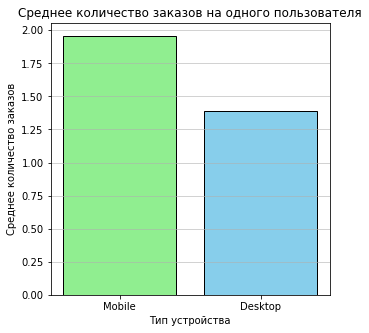

In [ ]:
plt.figure(figsize=(5, 5))

plt.bar(['Mobile', 'Desktop'], [mobile_orders_clean.mean(), desktop_orders_clean.mean()], color=['lightgreen', 'skyblue'], edgecolor='black')

plt.title('Среднее количество заказов на одного пользователя')
plt.xlabel('Тип устройства')
plt.ylabel('Среднее количество заказов')
plt.grid(axis='y', alpha=0.7)

plt.show()


После удаления выбросов различие между группами сохранилось: среднее количество заказов на одного пользователя составляет 1.96 заказа в мобильной группе против 1.39 заказа в стационарной группе. Разница между средними составляет около 0.57 заказа на пользователя в пользу мобильной группы.

При этом медианное значение в обеих группах составляет 1 заказ. Максимальное количество заказов после удаления выбросов снизилось до 6 заказов для мобильной группы и 3 заказов для стационарной, поэтому влияние экстремальных значений на сравнение средних существенно уменьшилось.

Таким образом, описательная статистика указывает на более высокое среднее количество заказов в мобильной группе. Для проверки того, является ли выявленное различие статистически значимым, проведём статистический тест.

Для проверки гипотезы используем односторонний t-тест Уэлча. Тест позволяет сравнить средние значения двух независимых групп. В данном случае размеры выборок различаются (9997 и 1472 пользователя), а стандартные отклонения также неодинаковы (1.34 и 0.65). Поэтому используем вариант теста Уэлча, который не предполагает равенства дисперсий.

In [ ]:
alpha = 0.05  # Уровень значимости

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    mobile_orders_clean,
    desktop_orders_clean,
    equal_var=False,
    alternative='greater'  # Среднее в mobile выше, чем в desktop
) 

if p_value_welch_ttest > alpha:
    print(f'p-value теста Уэлча = {p_value_welch_ttest:.2e}')
    print('Не отвергаем нулевую гипотезу.')
    print('Статистически значимых различий между средним количеством заказов в группах mobile и desktop не обнаружено.')
else:
    print(f'p-value теста Уэлча = {p_value_welch_ttest:.2e}')
    print('Отвергаем нулевую гипотезу в пользу альтернативной.')
    print('Среднее количество заказов в группе mobile статистически значимо выше, чем в группе desktop.')

В осенний период после удаления выбросов среднее количество заказов на одного пользователя составило 1.96 заказа в группе пользователей, совершавших заказы только с мобильных устройств, и 1.39 заказа в группе пользователей, совершавших заказы только со стационарных устройств. Разница между средними составляет около 0.57 заказа на пользователя в пользу мобильной группы.

По результатам одностороннего t-теста Уэлча получено p-value = 4.40 × 10⁻¹⁴¹, что значительно меньше выбранного уровня значимости α = 0.05. Поэтому нулевая гипотеза отвергается в пользу альтернативной.

Таким образом, имеются статистически значимые основания считать, что среднее количество заказов на одного пользователя среди пользователей, совершавших заказы только с мобильных устройств, выше, чем среди пользователей, совершавших заказы только со стационарных устройств.

При этом вывод относится только к пользователям, которые в осенний период совершали заказы исключительно с одного типа устройства. Пользователи, использовавшие оба типа устройств (20.5% от общего числа пользователей), были исключены из сравнения для формирования независимых выборок.

Теперь перейдем к проверке второй гипотезы. Сформулируем ее: 
- Гипотеза 2: Среднее время между заказами
    - H₀ (нулевая гипотеза): Среднее время между заказами пользователей мобильных приложений не превышает среднее время между заказами пользователей стационарных устройств.
    - H₁ (альтернативная гипотеза): Среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств.

Сначала сформируем две непересекающиеся группы пользователей: тех, кто совершал заказы только с мобильных устройств, и тех, кто использовал только стационарные устройства.

In [ ]:
# Пользователи только с mobile
mobile_users_h2 = user_device_orders[(user_device_orders['mobile'] > 0) & (user_device_orders['desktop'] == 0)]['user_id']

# Пользователи только с desktop
desktop_users_h2 = user_device_orders[(user_device_orders['desktop'] > 0) & (user_device_orders['mobile'] == 0)]['user_id']

Создадим отдельный датафрейм только с заказами этих пользователей. Пользователей, которые использовали оба типа устройств, в анализ второй гипотезы не включаем, чтобы группы не пересекались.

In [ ]:
hypothesis_2_df = autumn_df[autumn_df['user_id'].isin(pd.concat([mobile_users_h2, desktop_users_h2]))].copy()

Для первого заказа пользователя невозможно рассчитать интервал между текущей и предыдущей покупкой, поэтому такие строки содержат пропуск в `days_since_prev` и исключаются из анализа. Таким образом, пользователи с одним заказом за рассматриваемый период не формируют наблюдений для данной метрики. Их нужно удалить.

In [ ]:
hypothesis_2_df = hypothesis_2_df.dropna(subset=['days_since_prev'])

Теперь сформируем две выборки для статистического анализа. В них будет находиться количество дней между текущим заказом и предыдущей покупкой пользователя.

In [ ]:
# Время между заказами пользователей mobile
mobile_time = hypothesis_2_df.loc[hypothesis_2_df['device_type_canonical'] == 'mobile', 'days_since_prev']

# Время между заказами пользователей desktop
desktop_time = hypothesis_2_df.loc[hypothesis_2_df['device_type_canonical'] == 'desktop', 'days_since_prev']

Перед проведением статистического теста изучим распределение основной метрики - среднее время между заказами. 

In [ ]:
mobile_time.describe()

In [ ]:
desktop_time.describe()

Описательная статистика показывает, что среднее время между заказами составляет 13.79 дня для мобильной группы и 18.07 дня для стационарной группы. Таким образом, на исходных данных средний интервал между заказами в стационарной группе выше примерно на 4.28 дня.

При этом распределение метрики имеет выраженную правостороннюю асимметрию. В обеих группах присутствуют пользователи с достаточно большими интервалами между заказами: максимальное значение составляет 148 дней для мобильной группы и 146 дней для стационарной. Стандартное отклонение также значительно превышает среднее значение: 25.71 дня в мобильной группе и 32.66 дня в стационарной.

Таким образом, на исходных данных наблюдается более высокое среднее время между заказами в стационарной группе. Однако наличие экстремальных значений может влиять на среднее значение и результаты статистического теста.

Перед проведением статистического теста обработаем выбросы в обеих выборках. Для их определения используем правило межквартильного размаха (IQR): значения ниже Q1 − 1.5 × IQR и выше Q3 + 1.5 × IQR считаются выбросами и исключаются из выборки.

In [ ]:
# Функция для удаления выбросов по правилу IQR
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return series[(series >= lower_bound) & (series <= upper_bound)]

In [ ]:
# Удаляем выбросы из обеих выборок
mobile_time_clean = remove_outliers(mobile_time)
desktop_time_clean = remove_outliers(desktop_time)

In [ ]:
# Сравниваем размер выборок до и после удаления выбросов
print(f'Mobile: было {len(mobile_time)}, стало {len(mobile_time_clean)}')
print(f'Desktop: было {len(desktop_time)}, стало {len(desktop_time_clean)}')

После удаления выбросов по правилу IQR размер мобильной выборки уменьшился до 21374 наблюдений, а стационарной - до 1772. Это позволяет снизить влияние пользователей с экстремально больших значений интервала и перейти к сравнению средних значений на очищенных выборках. 

Далее повторно рассмотрим описательную статистику.

In [ ]:
mobile_time_clean.describe()

In [ ]:
desktop_time_clean.describe()

Для наглядного сравнения основной метрики визуализируем среднее время между заказами в мобильной и стационарной группах при помощи столбчатой диаграммы.

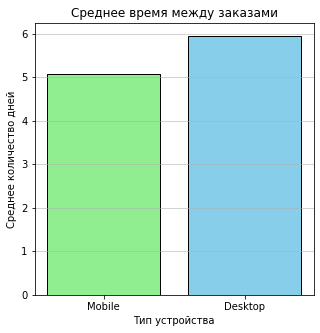

In [ ]:
plt.figure(figsize=(5, 5))

plt.bar(['Mobile', 'Desktop'], [mobile_time_clean.mean(), desktop_time_clean.mean()], 
        color=['lightgreen', 'skyblue'], edgecolor='black')

plt.title('Среднее время между заказами')
plt.xlabel('Тип устройства')
plt.ylabel('Среднее количество дней')
plt.grid(axis='y', alpha=0.7)

plt.show()

После удаления выбросов среднее время между заказами снизилось в обеих группах: до 5.08 дня в мобильной группе и до 5.95 дня в стационарной. При этом стационарная группа по-прежнему имеет более высокий средний интервал между заказами - примерно на 0.87 дня.

Медианное значение в обеих группах составляет 0 дней, что говорит о наличии большого количества повторных заказов в тот же день. Максимальный интервал после удаления выбросов составляет 37 дней для мобильной группы и 55 дней для стационарной.

Таким образом, после обработки выбросов среднее время между заказами остается выше у пользователей стационарных устройств. 

Для проверки статистической значимости различия используем односторонний t-тест Уэлча. Тест позволяет сравнить средние значения двух групп. В данном случае размеры выборок и их стандартные отклонения различаются, поэтому используем вариант теста Уэлча, не предполагающий равенства дисперсий.

In [ ]:
alpha = 0.05  # Уровень значимости

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    mobile_time_clean,
    desktop_time_clean,
    equal_var=False,
    alternative='greater'  # Проверяем, что среднее время в mobile выше, чем в desktop
)  

if p_value_welch_ttest > alpha:
    print(f'p-value теста Уэлча = {p_value_welch_ttest:.2e}')
    print('Не отвергаем нулевую гипотезу.')
    print('Статистически значимых оснований считать, что среднее время между заказами в mobile выше, чем в desktop, нет.')
else:
    print(f'p-value теста Уэлча = {p_value_welch_ttest:.2e}')
    print('Отвергаем нулевую гипотезу в пользу альтернативной.')
    print('Среднее время между заказами в группе mobile статистически значимо выше, чем в группе desktop.')

В осенний период после удаления выбросов среднее время между заказами составило 5.08 дня для пользователей, совершавших заказы только с мобильных устройств, и 5.95 дня для пользователей, совершавших заказы только со стационарных устройств. Таким образом, среднее время между заказами в мобильной группе оказалось примерно на 0.87 дня меньше, чем в стационарной, что не соответствует направлению проверяемой гипотезы.

По результатам одностороннего t-теста Уэлча получено p-value = 9.97 × 10⁻¹, что значительно превышает выбранный уровень значимости α = 0.05. Поэтому нулевая гипотеза не отвергается.

Таким образом, статистически значимых оснований считать, что среднее время между заказами пользователей мобильных устройств выше, чем у пользователей стационарных устройств, не обнаружено. Более того, выборочные средние указывают на обратную тенденцию: после удаления выбросов пользователи мобильных устройств в среднем совершают повторные заказы с меньшим интервалом, чем пользователи стационарных устройств.

При этом при интерпретации результата необходимо учитывать качество исходных данных. В показателе `days_since_prev` могут присутствовать ошибки и неточности, которые способны влиять на рассчитанные интервалы между заказами и, соответственно, на результаты анализа.

## Общий вывод и рекомендации

**Общий вывод:**

В ходе проекта были проанализированы данные о бронировании билетов на сервисе Яндекс Афиша за период с июня по октябрь 2024 года. Основной датасет содержит 290849 заказов, информацию о пользователях, мероприятиях, устройствах, выручке и количестве приобретённых билетов. После предобработки, удаления выбросов и дубликатов, а также исключения заказов без информации о соответствующих мероприятиях, для анализа осталось 287694 заказа.

Исследовательский анализ показал устойчивый рост пользовательской активности в рассматриваемый период: количество заказов увеличивалось каждый месяц и достигло максимума в октябре - 99263 заказа. Осенью изменилась структура спроса: доля театральных и спортивных мероприятий выросла, при этом концерты сохранили первое место по популярности. Пользователи преимущественно оформляли заказы с мобильных устройств - около 80% заказов, как летом, так и осенью.

Средняя выручка с одного билета осенью снизилась в большинстве категорий мероприятий. Наиболее заметное снижение наблюдалось у театра, концертов и елок. При этом у стендапа и выставок средняя выручка с одного билета немного выросла.

Осенью также наблюдался рост количества активных пользователей и заказов. Наиболее высокая активность приходилась преимущественно на середину рабочей недели, особенно на вторник и четверг, а минимальная - на выходные. Отдельные дни характеризовались резкими всплесками заказов и одновременным снижением средней стоимости билета.

Анализ регионов показал высокую концентрацию заказов: Каменевский регион и Североярская область обеспечили около 40% всех заказов осенью. Среди билетных партнеров лидером по выручке стал «Билеты без проблем» с долей 14.8%. Три крупнейших партнёера обеспечили около 41% всей выручки. При этом лидер по количеству представленных мероприятий не всегда являлся лидером по заказам или выручке.

Для проверки гипотез были отобраны пользователи, использующие только один тип устройства (только мобильное или только стационарное), что обеспечило независимость сравниваемых групп. В мобильную группу вошло 9997 пользователей, в стационарную - 1472 пользователей. Статистический анализ подтвердил первую гипотезу: среднее количество заказов на пользователя в мобильной группе составило 1.96 против 1.39 в стационарной группе. Односторонний тест Уэлча дал p-value = 4.40 × 10⁻¹⁴¹, поэтому нулевая гипотеза была отвергнута. Получены статистически значимые основания считать, что мобильные пользователи совершают больше заказов.

Вторая гипотеза о большем времени между заказами у мобильных пользователей не подтвердилась. Для анализа были отобраны пользователи с двумя и более заказами на одном типе устройства. Среднее время между заказами составило 5.08 дня для мобильных пользователей и 5.95 дня для стационарных. Полученное p-value = 9.97 × 10⁻¹ не позволяет отвергнуть нулевую гипотезу. Более того, выборочные средние показывают обратную тенденцию: в мобильной группе интервал между заказами оказался меньше, чем в стационарной.

**Рекомендации:**
- Сфокусироваться на мобильном сегменте, так как около 80% заказов совершается с мобильных устройств, а среднее количество заказов на пользователя статистически значимо выше. 
- Учитывать сезонность спроса - осенью значительно увеличивается количество заказов, особенно в октябре. Стоит заранее готовить маркетинговые кампании и увеличивать предложение наиболее востребованных категорий — концертов, театра и спорта.
- Использовать периоды повышенной активности. Вторник и четверг характеризуются повышенной активностью пользователей. Эти дни можно рассматривать как потенциально эффективные периоды для продвижения мероприятий и специальных предложений.
- Отдельно изучить причины пиковых дней. Резкие всплески заказов одновременно со снижением средней стоимости билета могут быть связаны с акциями, распродажами. Стоит проверить конкретные события и кампании в эти даты.
- Учитывать концентрацию заказов и выручки среди партнеров и регионов. Основные показатели формируются ограниченным числом участников, поэтому важно контролировать зависимость от крупнейших регионов и билетных партнеров и одновременно искать возможности для развития менее представленных регионов и партнеров.
- Для более глубокого анализа рекомендуется провести исследование пользователей, использующих оба типа устройств, так как они были исключены из статистического теста для обеспечения его корректности, но могут представлять собой ценную аудиторию.